# 02.00 — Protocol và input đã khóa

Câu hỏi: input đã đủ để bắt đầu Phase 02 chưa? Trả lời bằng Phase 01 gate, checksum, protocol và mẫu review đã khóa. Notebook không tải model và không đọc IT Test/General Test. Sơ đồ được hiển thị từ file local ở cell đầu tiên.

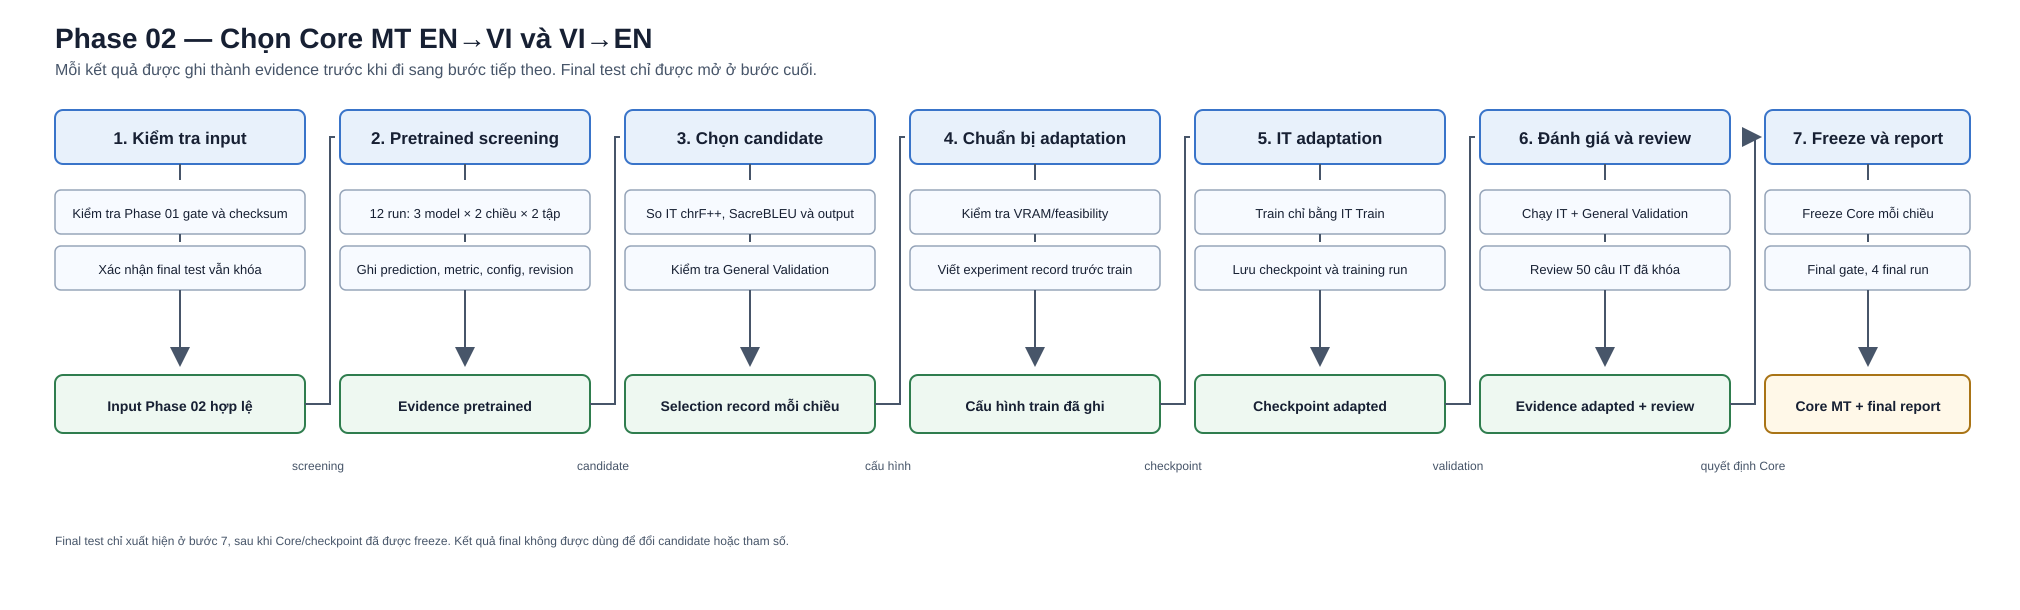

('Select one EN-to-VI Core MT and one VI-to-EN Core MT for later compact deployment research. This phase does not claim that a teacher runs on the target weak device.',
 'Open exactly once only after the Core MT decision for both directions is written and frozen. Final results cannot change the selected Core MT.')

In [1]:
from pathlib import Path
import hashlib, json
from IPython.display import SVG, display

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'configs/phase02_protocol.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Cannot locate the project root containing configs/phase02_protocol.json.')
protocol = json.loads((ROOT / 'configs/phase02_protocol.json').read_text(encoding='utf-8'))
display(SVG(data=(ROOT / 'docs/phase_02/workflow.svg').read_text(encoding='utf-8')))
protocol['goal'], protocol['data_roles']['locked_final_evaluation']['access_rule']

In [2]:
allowed = {
    'IT Train': ROOT / 'data/processed/it_en_vi/train.jsonl',
    'IT Validation': ROOT / 'data/processed/it_en_vi/validation.jsonl',
    'General Validation': ROOT / 'data/processed/general_validation_en_vi/general_validation.jsonl',
}
def digest(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()
for role, path in allowed.items():
    lines = sum(1 for _ in path.open(encoding='utf-8'))
    print(f'{role}: {lines:,} rows | sha256={digest(path)} | {path.relative_to(ROOT)}')
print('Final test paths are intentionally absent from this notebook.')

IT Train: 121,547 rows | sha256=d6dbad4f61a57289935465a05194dd1d88003c2d63c55b90698dd19f10f1b98e | data\processed\it_en_vi\train.jsonl
IT Validation: 15,253 rows | sha256=022eb09d7a4a8853902b943f22959b0fb69bf92356575bfd87ab7913aa02a8ad | data\processed\it_en_vi\validation.jsonl
General Validation: 997 rows | sha256=11dd3ca7091dea46e95d5e56933fcc676ef48f612157f044a583a895a6991d4f | data\processed\general_validation_en_vi\general_validation.jsonl
Final test paths are intentionally absent from this notebook.


In [3]:
manifest = json.loads((ROOT / 'reviews/phase02_it_validation_review_manifest.json').read_text(encoding='utf-8'))
assert manifest['rows'] == 50
print(manifest['selection_rule'])
print(f"Sealed review rows: {manifest['rows']}")

All available tagged validation rows containing path or command are prioritized; remaining rows are selected deterministically by SHA-256(phase02-review:row_id).
Sealed review rows: 50
